In [113]:
%matplotlib widget
%reload_ext autoreload
%autoreload 2

import numpy as np
import json, os, math, glob
import importlib
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import clear_output, display

from alvra_tools.utils import *
from alvra_tools.channels import *
from alvra_tools.analysis_apo import *
from alvra_tools.alvra_widgets import Rebin_widget
from IPython.display import display

import warnings
warnings.filterwarnings('ignore')

In [123]:
pgroup = 'p22591'
runlist = [27]
#runlist = np.arange(73, 84)

data, meta = merge_multiple_runs(pgroup, runlist)

Processing run 27


100%|██████████| 16/16 [00:01<00:00,  9.39it/s]


In [124]:
ui, out = Rebin_widget(data=data)

display(ui)

In [110]:
out["results1"] = Rebin_with_scanvar_and_filter(signal='diode1', data=data, quantile=0.7, izero='Izero122', TT='126', YAGscan=False, withTT=False)
out["results2"] = Rebin_with_scanvar_and_filter(signal='diode2', data=data, quantile=0.7, izero='Izero122', TT='126', YAGscan=False, withTT=False)
out["params"]   = {'signal1': 'diode1', 'signal2': 'diode2', 'izero': 'Izero122', 'quantile': 0.7, 'TT': '126', 'YAGscan': False, 'withTT': False}

Izero122_pump diode1_pump
1949 shots out of 3966 survived
Izero122_pump diode2_pump
1947 shots out of 3966 survived


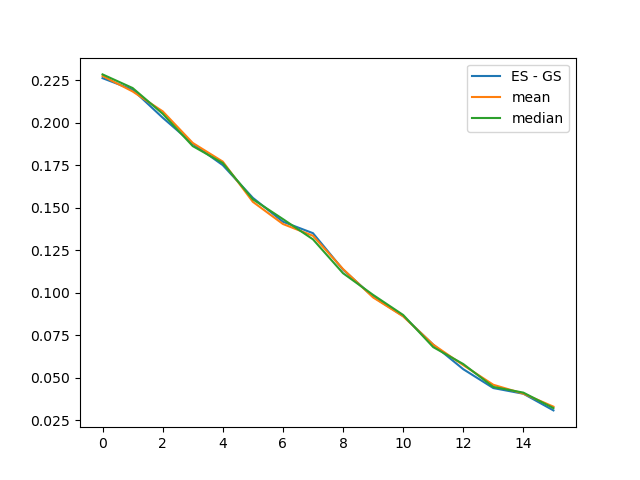

In [130]:
plt.figure()
plt.plot(data_plot1['results']['ES'] - data_plot1['results']['GS'], label ='ES - GS' )
plt.plot(data_plot1['results']['err_pp'], label = 'mean')
plt.plot(data_plot1['results']['pp'], label = 'median')
plt.legend(loc='best')
plt.show()

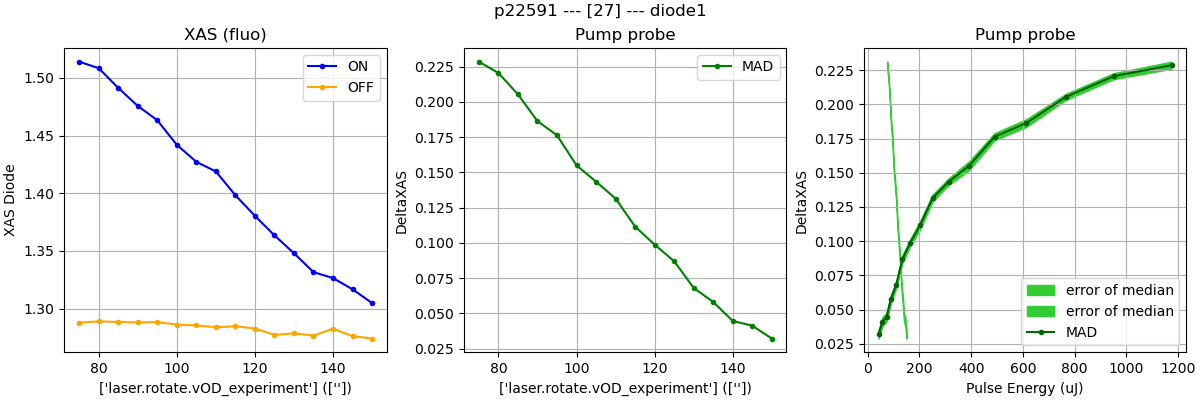

In [129]:
paramsFit = np.load('/sf/alvra/data/{}/work/alvra_beamline_scripts/fitvalues.npy'.format(pgroup))

data_plot1 = {"results": out['results1'], "params": out['params'], "which": "signal1"}
#data_plot2 = {"results": out['results2'], "params": out['params'], "which": "signal2"}

fig, axes = plotter.fluence_scans(data_plot1, meta, paramsFit, errbars=False)
#fig, axes = plotter.fluence_scans(data_plot2, meta, paramsFit)
